In [1]:

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor


## CARGAR Y PREPARAR DATOS

In [2]:
# Reutiliza la función de limpieza del notebook 01

def limpiar_con_logica_nyc(df, etiqueta):
    antes = len(df)
    if 'tpep_pickup_datetime' in df.columns:
        df = df.rename(columns={'tpep_pickup_datetime': 'pickup_dt', 'tpep_dropoff_datetime': 'dropoff_dt'})
    else:
        df = df.rename(columns={'lpep_pickup_datetime': 'pickup_dt', 'lpep_dropoff_datetime': 'dropoff_dt'})

    df['duration_min'] = (df['dropoff_dt'] - df['pickup_dt']).dt.total_seconds() / 60
    df['trip_km']      = df['trip_distance'] * 1.609

    df_c = df[
        (df['trip_distance'] > 0.18) &
        (df['trip_distance'] < 100) &
        (df['fare_amount']   > 3.0) &
        (df['PULocationID']  <= 263) &
        (df['DOLocationID']  <= 263) &
        (df['PULocationID']  != df['DOLocationID']) &
        (df['duration_min']  > 1) &
        (df['duration_min']  < 300) &
        (df['fare_amount']   < 600)
    ].copy()
    print(f"{etiqueta}: {antes} → {len(df_c)} registros")
    return df_c

# Cargar los 4 datasets
df_y_mar = limpiar_con_logica_nyc(pd.read_parquet('../dataset/yellow_tripdata_2025-03.parquet'), "Yellow Marzo")
df_y_nov = limpiar_con_logica_nyc(pd.read_parquet('../dataset/yellow_tripdata_2025-11.parquet'), "Yellow Noviembre")
df_g_mar = limpiar_con_logica_nyc(pd.read_parquet('../dataset/green_tripdata_2025-03.parquet'),  "Green Marzo")
df_g_nov = limpiar_con_logica_nyc(pd.read_parquet('../dataset/green_tripdata_2025-11.parquet'),  "Green Noviembre")

# Etiquetar flota (0 = Yellow, 1 = Green)
df_y_mar['fleet'] = 0;  df_y_nov['fleet'] = 0
df_g_mar['fleet'] = 1;  df_g_nov['fleet'] = 1

# Unir todo
df_all = pd.concat([df_y_mar, df_y_nov, df_g_mar, df_g_nov], ignore_index=True)
print(f"\nTotal registros para entrenamiento: {len(df_all):,}")

Yellow Marzo: 4145257 → 3635976 registros
Yellow Noviembre: 4181444 → 3358117 registros
Green Marzo: 51539 → 42014 registros
Green Noviembre: 46912 → 37260 registros

Total registros para entrenamiento: 7,073,367


## FEATURE ENGINEERING

In [3]:
df_all['hour']        = df_all['pickup_dt'].dt.hour
df_all['day_of_week'] = df_all['pickup_dt'].dt.dayofweek
df_all['month_num']   = df_all['pickup_dt'].dt.month
df_all['is_weekend']  = (df_all['day_of_week'] >= 5).astype(int)

# Features finales
FEATURES = [
    'PULocationID', 'DOLocationID',
    'trip_distance',
    'hour', 'day_of_week', 'month_num',
    'is_weekend', 'fleet'
]

TARGET_DURATION = 'duration_min'
TARGET_FARE     = 'fare_amount'

# Eliminar nulos en features
df_model = df_all[FEATURES + [TARGET_DURATION, TARGET_FARE]].dropna()
print(f"Registros tras eliminar NaN en features: {len(df_model):,}")



Registros tras eliminar NaN en features: 7,073,367


## TRAIN / TEST SPLIT

In [4]:
X = df_model[FEATURES]
y_dur  = df_model[TARGET_DURATION]
y_fare = df_model[TARGET_FARE]

X_sample, _, y_dur_s, _, y_fare_s, _ = train_test_split(
    X, y_dur, y_fare, test_size=0.70, random_state=42
)

X_train, X_test, y_dur_train, y_dur_test = train_test_split(
    X_sample, y_dur_s, test_size=0.20, random_state=42
)
_, _, y_fare_train, y_fare_test = train_test_split(
    X_sample, y_fare_s, test_size=0.20, random_state=42
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 1,697,608  |  Test: 424,402


## ENTRENAR MODELOS XGBOOST

In [5]:
params = {
    'n_estimators':    300,
    'max_depth':       6,
    'learning_rate':   0.1,
    'subsample':       0.8,
    'colsample_bytree': 0.8,
    'random_state':    42,
    'n_jobs':          -1,
    'tree_method':     'hist'   # más rápido en CPU
}

print("\n[1/2] Entrenando modelo de DURACIÓN...")
model_duration = XGBRegressor(**params)
model_duration.fit(X_train, y_dur_train,
                   eval_set=[(X_test, y_dur_test)],
                   verbose=50)

print("\n[2/2] Entrenando modelo de TARIFA...")
model_fare = XGBRegressor(**params)
model_fare.fit(X_train, y_fare_train,
               eval_set=[(X_test, y_fare_test)],
               verbose=50)


[1/2] Entrenando modelo de DURACIÓN...
[0]	validation_0-rmse:12.66943
[50]	validation_0-rmse:6.63335
[100]	validation_0-rmse:6.38708
[150]	validation_0-rmse:6.26415
[200]	validation_0-rmse:6.19362
[250]	validation_0-rmse:6.13220
[299]	validation_0-rmse:6.09015

[2/2] Entrenando modelo de TARIFA...
[0]	validation_0-rmse:14.33548
[50]	validation_0-rmse:5.23205
[100]	validation_0-rmse:5.09829
[150]	validation_0-rmse:5.04257
[200]	validation_0-rmse:4.99707
[250]	validation_0-rmse:4.95344
[299]	validation_0-rmse:4.92308


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## EVALUACIÓN

In [6]:
def evaluar(model, X_test, y_test, nombre):
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    print(f"\n── {nombre} ──")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    return y_pred

y_dur_pred  = evaluar(model_duration, X_test, y_dur_test,  "DURACIÓN (min)")
y_fare_pred = evaluar(model_fare,     X_test, y_fare_test, "TARIFA ($)")


── DURACIÓN (min) ──
  MAE  : 3.64
  RMSE : 6.09
  R²   : 0.7998

── TARIFA ($) ──
  MAE  : 2.67
  RMSE : 4.92
  R²   : 0.9016


## IMPORTANCIA DE FEATURES

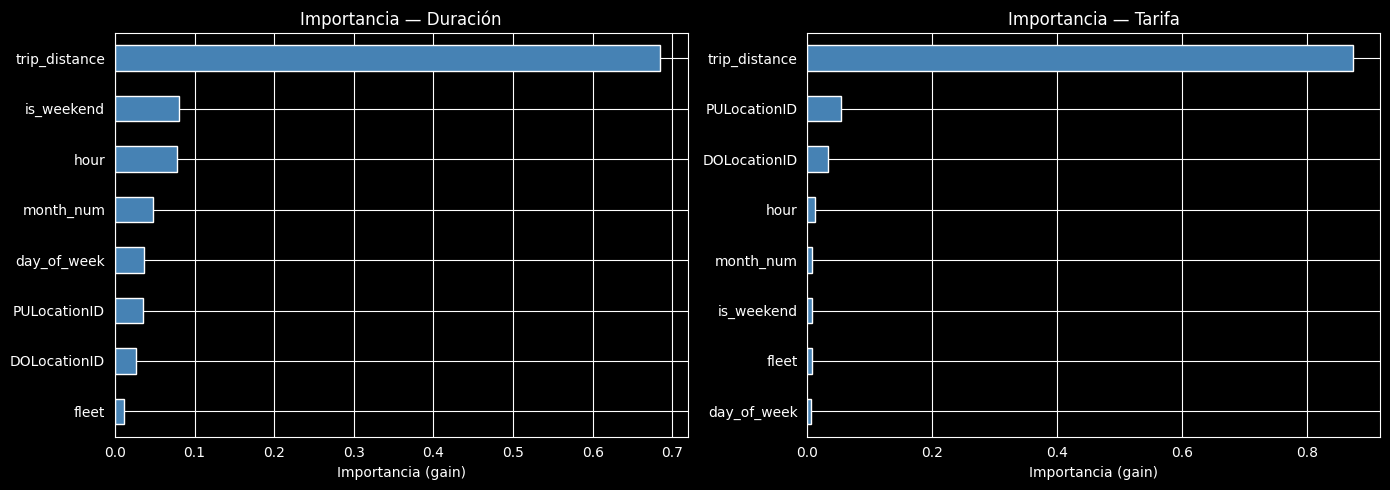

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title in [
    (axes[0], model_duration, "Importancia — Duración"),
    (axes[1], model_fare,     "Importancia — Tarifa")
]:
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importancia (gain)")

plt.tight_layout()
plt.show()


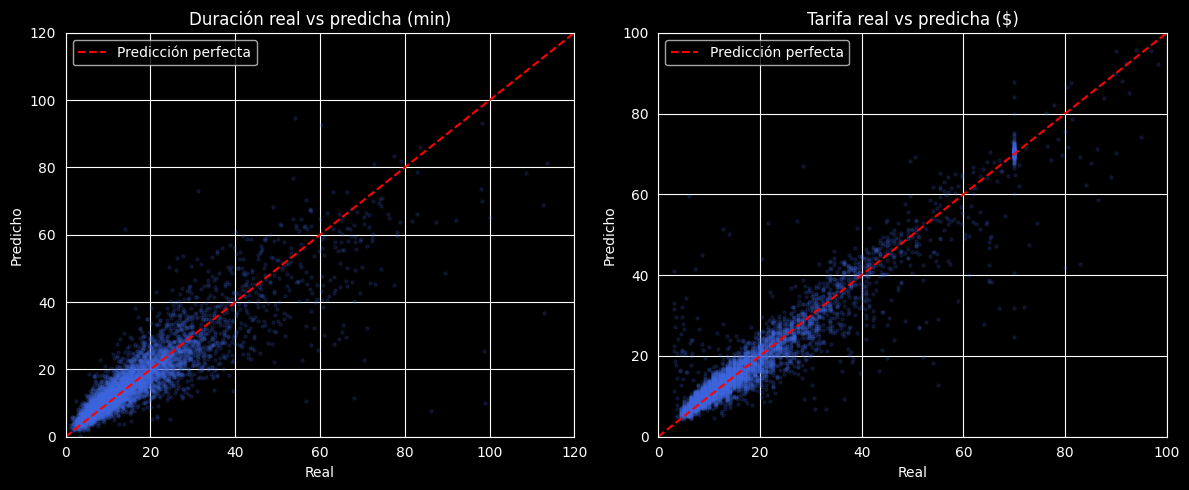

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_real, y_pred, title, lim in [
    (axes[0], y_dur_test,  y_dur_pred,  "Duración real vs predicha (min)", 120),
    (axes[1], y_fare_test, y_fare_pred, "Tarifa real vs predicha ($)",      100)
]:
    ax.scatter(y_real[:5000], y_pred[:5000], alpha=0.15, s=5, color='royalblue')
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlim(0, lim);  ax.set_ylim(0, lim)
    ax.set_xlabel("Real");  ax.set_ylabel("Predicho")
    ax.set_title(title);    ax.legend()

plt.tight_layout()
plt.show()

## FUNCIÓN DE PREDICCIÓN (Streamlit)

In [12]:
def predecir_viaje(pu_id, do_id, hora, distancia_millas,
                   dia_semana=1, mes=3, es_fin_semana=0, flota=0):
    """
    Parámetros:
        pu_id             : PULocationID (1-263)
        do_id             : DOLocationID (1-263)
        hora              : 0-23
        distancia_millas  : estimada (puede ser el promedio histórico del par PU/DO)
        dia_semana        : 0=Lunes ... 6=Domingo
        mes               : 1-12
        es_fin_semana     : 0/1
        flota             : 0=Yellow, 1=Green
    Retorna:
        dict con duracion_min y coste estimados
    """
    X = pd.DataFrame([[pu_id, do_id, distancia_millas, hora,
                        dia_semana, mes, es_fin_semana, flota]],
                     columns=FEATURES)
    dur  = model_duration.predict(X)[0]
    fare = model_fare.predict(X)[0]
    return {
        'duracion_min': round(dur, 1),
        'coste_usd':    round(fare, 2)
    }

##  Ejemplo de uso

In [13]:
print("\n── EJEMPLO DE PREDICCIÓN ──")
resultado = predecir_viaje(pu_id=161, do_id=237, hora=9,
                           distancia_millas=2.5, dia_semana=1, mes=3)
print(f"  Zona 161 (Midtown Center) → Zona 237 (Upper East Side South)")
print(f"  Hora: 9:00 | Distancia estimada: 2.5 millas")
print(f"  Duración predicha : {resultado['duracion_min']} min")
print(f"  Coste predicho    : ${resultado['coste_usd']}")


── EJEMPLO DE PREDICCIÓN ──
  Zona 161 (Midtown Center) → Zona 237 (Upper East Side South)
  Hora: 9:00 | Distancia estimada: 2.5 millas
  Duración predicha : 20.899999618530273 min
  Coste predicho    : $19.75


In [16]:
import os

# Guarda los modelos en la carpeta src/ junto a la app
save_dir = os.path.join(os.path.dirname(os.getcwd()), 'src/models')
os.makedirs(save_dir, exist_ok=True)

joblib.dump(model_duration, os.path.join(save_dir, 'model_duration.pkl'))
joblib.dump(model_fare,     os.path.join(save_dir, 'model_fare.pkl'))

print(f"Modelos guardados en: {save_dir}")
print(f"  model_duration.pkl")
print(f"  model_fare.pkl")

Modelos guardados en: /home/i2cat/Masterdata/Taxi_app.ai/taxi_app.ai/src/models
  model_duration.pkl
  model_fare.pkl


In [20]:
dist_media = (df_all.groupby(['PULocationID','DOLocationID'])['trip_distance']
              .mean().reset_index()
              .rename(columns={'trip_distance': 'dist_media_millas'}))

# Guardar junto a los modelos
dist_media.to_csv(os.path.join(save_dir, 'dist_media.csv'), index=False)
print(f"Pares guardados: {len(dist_media)}")

Pares guardados: 43128
